# Treść zadania

Proszę wybrać odpowiednią metodę dla zadania związanego z danymi tabelarycznymi, które mogą dotyczyć takich problemów jak klasyfikacja, regresja czy rekomendacja. Należy zaimplementować model (np. regresję liniową, drzewa decyzyjne, lasy losowe, XGBoost oraz różne sieci neuronowe) i przeprowadzić proces optymalizacji, próbując dla wybranego zbioru danych osiągnąć jak nalepsze wyniki, pokazując cały proces dochodzenia do najlepszego rozwiązania, sterowany poprzednimi wynikami, porównaniami i wnioskami. Kluczowym elementem będzie eksperymentowanie z hyperparametrami modeli, regularyzacją oraz zastosowanie walidacji krzyżowej, aby uzyskać jak najlepsze wyniki na danych testowych. Należy również wykonać analizę wyników.
Wysyłany do oceny notebook powinien mieć nazwę: GGSN_Imię_Nazwisko_Zad1.


# Gaming and Mental Health — Machine Learning Project

## 1. Introduction

The goal of this project is to build and optimize machine learning models for a tabular dataset related to gaming behavior and mental health indicators.

The dataset contains demographic information, gaming habits, lifestyle variables, psychological scores, and an addiction level indicator.

This dataset is **synthetic**, unfortunately **not a real survey**.

The main objective of this project is:

- to predict **addiction_level** using supervised learning
- to compare multiple models
- to optimize hyperparameters
- to evaluate performance using cross-validation
- to analyze feature importance and model behavior

We will follow a structured workflow:

1. Introduction
2. Data loading
3. Exploratory Data Analysis
4. Data preprocessing
5. Baseline model
6. Model comparison
7. Hyperparameter tuning
8. Final model
9. Results analysis
10. Conclusions

Target variable: **addiction_level**
Problem type: **regression**

## 2. Data loading

In this section we load the dataset and inspect its basic structure:
- number of rows
- number of columns
- column names
- data types
- missing values

In [48]:
import os

cpu_count = os.cpu_count()
n_my_jobs = max(1, cpu_count - 2)
print(cpu_count, n_my_jobs)

12 10


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set(style="whitegrid")

In [2]:
DATA_PATH = Path("../data/gaming_mental_health_10M_40features.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(1000000, 39)

In [3]:
df.head()

,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


In [4]:
df.columns.tolist()

['age',
 'gender',
 'income',
 'daily_gaming_hours',
 'weekly_sessions',
 'years_gaming',
 'sleep_hours',
 'caffeine_intake',
 'exercise_hours',
 'stress_level',
 'anxiety_score',
 'depression_score',
 'social_interaction_score',
 'relationship_satisfaction',
 'academic_performance',
 'work_productivity',
 'addiction_level',
 'multiplayer_ratio',
 'toxic_exposure',
 'violent_games_ratio',
 'mobile_gaming_ratio',
 'night_gaming_ratio',
 'weekend_gaming_hours',
 'friends_gaming_count',
 'online_friends',
 'streaming_hours',
 'esports_interest',
 'headset_usage',
 'microtransactions_spending',
 'parental_supervision',
 'loneliness_score',
 'aggression_score',
 'happiness_score',
 'bmi',
 'screen_time_total',
 'eye_strain_score',
 'back_pain_score',
 'competitive_rank',
 'internet_quality']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 39 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   age                         1000000 non-null  int64  
 1   gender                      1000000 non-null  object 
 2   income                      1000000 non-null  int64  
 3   daily_gaming_hours          1000000 non-null  float64
 4   weekly_sessions             1000000 non-null  int64  
 5   years_gaming                1000000 non-null  int64  
 6   sleep_hours                 1000000 non-null  float64
 7   caffeine_intake             1000000 non-null  float64
 8   exercise_hours              1000000 non-null  float64
 9   stress_level                1000000 non-null  int64  
 10  anxiety_score               1000000 non-null  float64
 11  depression_score            1000000 non-null  float64
 12  social_interaction_score    1000000 non-null  float64
 13

In [6]:
df.isna().sum().sort_values(ascending=False)

age                           0
gender                        0
income                        0
daily_gaming_hours            0
weekly_sessions               0
years_gaming                  0
sleep_hours                   0
caffeine_intake               0
exercise_hours                0
stress_level                  0
anxiety_score                 0
depression_score              0
social_interaction_score      0
relationship_satisfaction     0
academic_performance          0
work_productivity             0
addiction_level               0
multiplayer_ratio             0
toxic_exposure                0
violent_games_ratio           0
mobile_gaming_ratio           0
night_gaming_ratio            0
weekend_gaming_hours          0
friends_gaming_count          0
online_friends                0
streaming_hours               0
esports_interest              0
headset_usage                 0
microtransactions_spending    0
parental_supervision          0
loneliness_score              0
aggressi

In [7]:
df.duplicated().sum()

np.int64(0)

### Observations

- The dataset contains approximately 1 million rows.
- Most columns are numeric.
- Gender is categorical.
- Target variable: addiction_level
- Missing values: (fill after running)
- Duplicates: (fill after running)

This dataset is large, so for visualization we will use a sample.

## 3. Exploratory Data Analysis

The goal of EDA is to:

- understand distributions
- detect outliers
- check correlations
- inspect the target variable
- find important features

Because the dataset is large, we will use a sample for visualization.

In [8]:
SAMPLE_SIZE = 100_000

if len(df) > SAMPLE_SIZE:
    df_sample = df.sample(SAMPLE_SIZE, random_state=42)
else:
    df_sample = df.copy()

df_sample.shape

(100000, 39)

### Target variable distribution

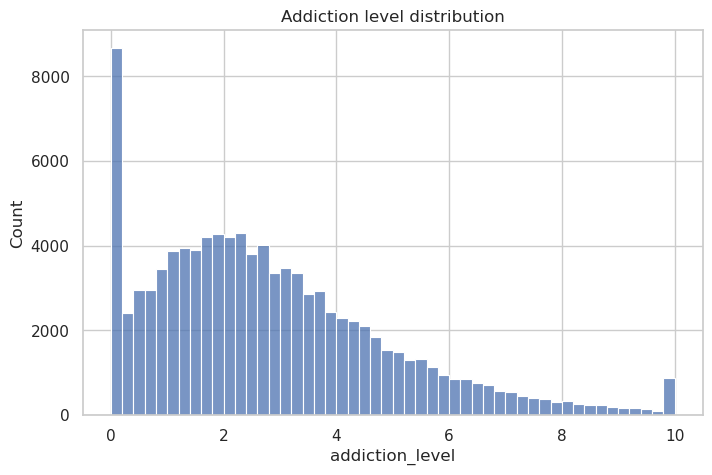

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_sample["addiction_level"], bins=50)
plt.title("Addiction level distribution")
plt.show()

In [10]:
numeric_cols = df_sample.select_dtypes(include=np.number).columns.tolist()

len(numeric_cols)

38

### Key gaming variables

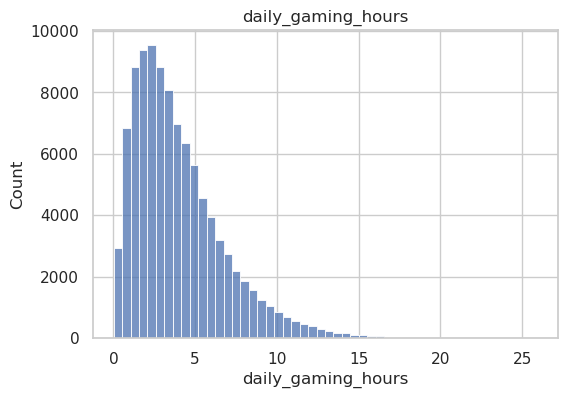

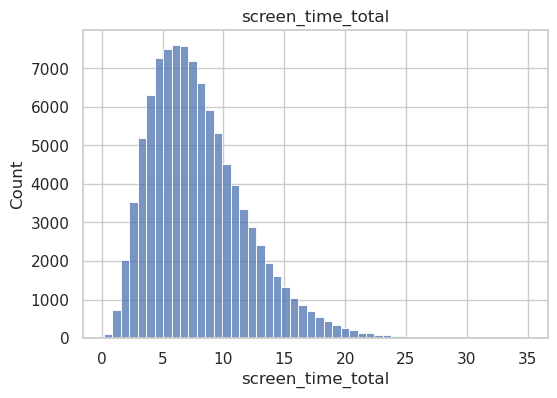

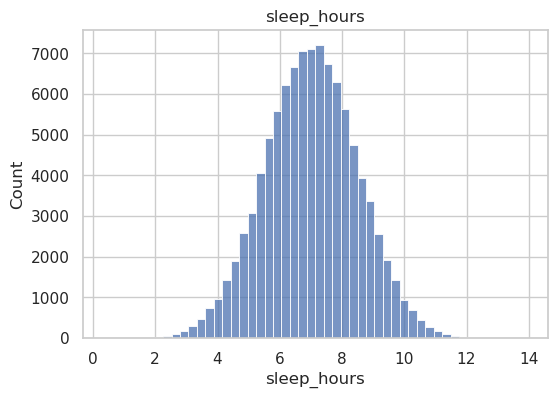

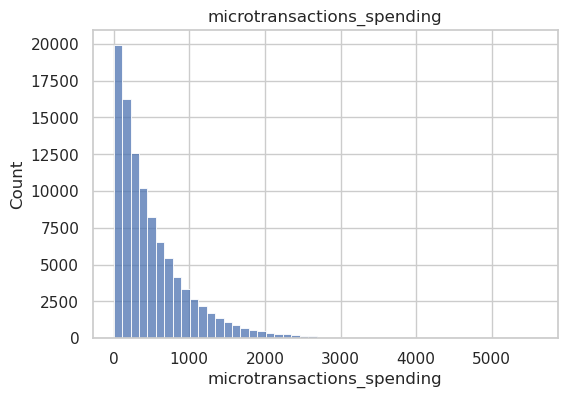

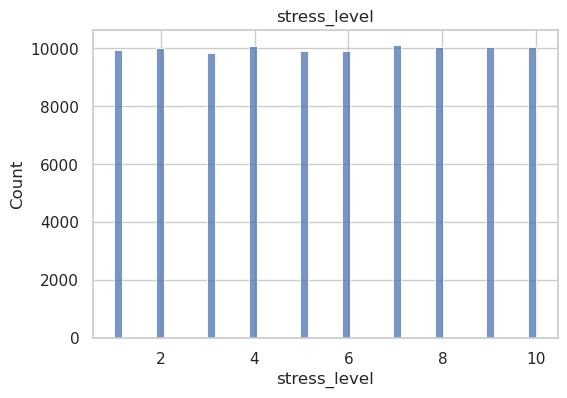

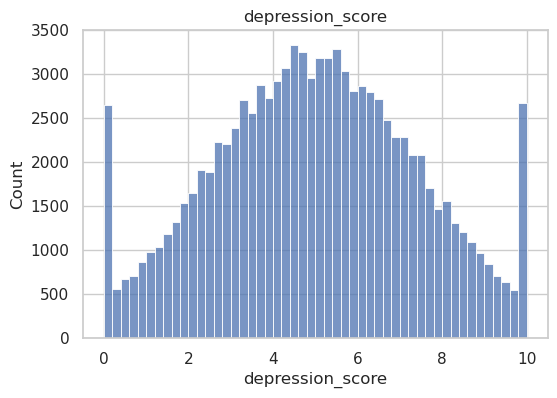

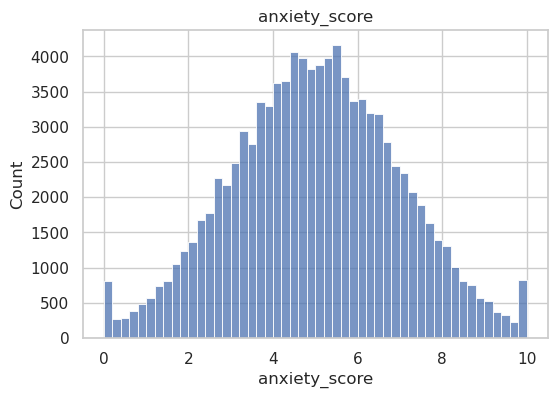

In [11]:
key_cols = [
    "daily_gaming_hours",
    "screen_time_total",
    "sleep_hours",
    "microtransactions_spending",
    "stress_level",
    "depression_score",
    "anxiety_score"
]

for col in key_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_sample[col], bins=50)
    plt.title(col)
    plt.show()

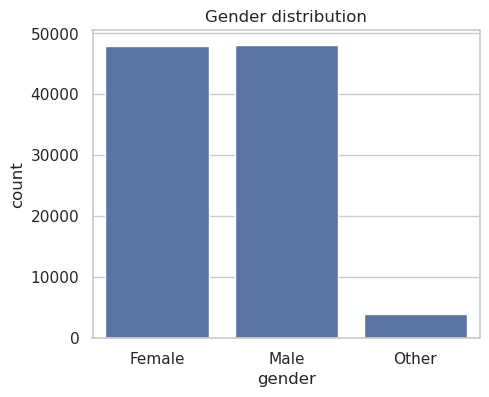

In [12]:
if "gender" in df_sample.columns:
    plt.figure(figsize=(5,4))
    sns.countplot(x=df_sample["gender"])
    plt.title("Gender distribution")
    plt.show()

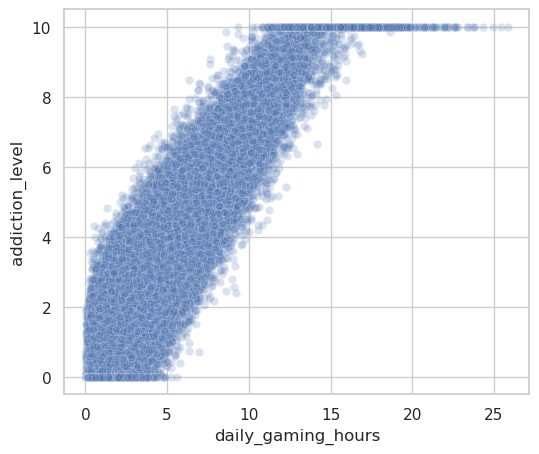

In [13]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df_sample["daily_gaming_hours"],
    y=df_sample["addiction_level"],
    alpha=0.2
)
plt.show()

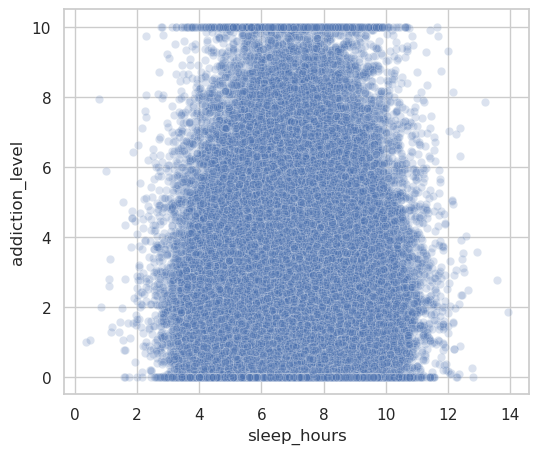

In [14]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df_sample["sleep_hours"],
    y=df_sample["addiction_level"],
    alpha=0.2
)
plt.show()

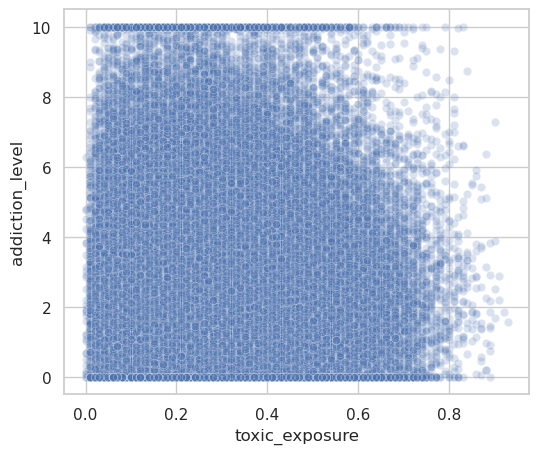

In [15]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df_sample["toxic_exposure"],
    y=df_sample["addiction_level"],
    alpha=0.2
)
plt.show()

### Correlation matrix (numeric features)

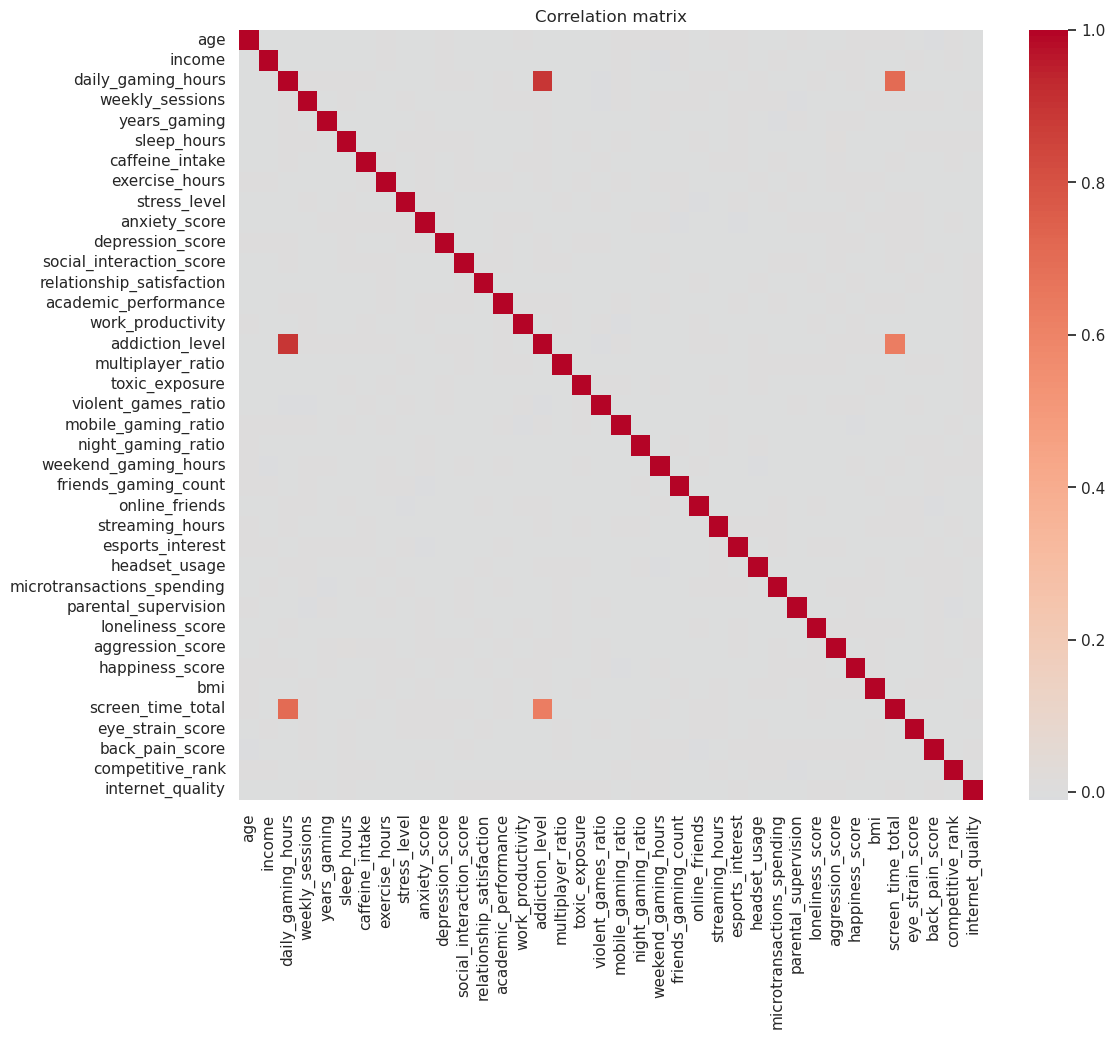

In [16]:
corr = df_sample[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=False
)
plt.title("Correlation matrix")
plt.show()

In [17]:
target_corr = corr["addiction_level"].sort_values(ascending=False)

target_corr.head(15)

addiction_level             1.000000
daily_gaming_hours          0.891345
screen_time_total           0.631019
streaming_hours             0.006042
online_friends              0.005365
headset_usage               0.004888
caffeine_intake             0.003761
sleep_hours                 0.003544
years_gaming                0.003285
weekly_sessions             0.002891
academic_performance        0.002621
social_interaction_score    0.002546
happiness_score             0.002520
aggression_score            0.002180
depression_score            0.002080
Name: addiction_level, dtype: float64

### EDA conclusions

We observe:

- addiction_level strongly correlates with gaming time variables
- psychological scores also show correlation
- some variables have skewed distributions
- no obvious data corruption detected

## 4. Data preprocessing

In this section we prepare the data for machine learning.

Steps:

1. Remove duplicates
2. Handle missing values
3. Define target variable
4. Select features
5. Encode categorical variables
6. Train / test split
7. Scaling
8. Build preprocessing pipeline

### Remove duplicate rows

In [18]:
df = df.drop_duplicates()

df.shape

(1000000, 39)

### Remove rows with missing target

In [19]:
TARGET = "addiction_level"

df = df[df[TARGET].notna()]

df.shape

(1000000, 39)

### Missing values check

In [20]:
missing = df.isna().sum().sort_values(ascending=False)

missing.head(20)

age                          0
gender                       0
income                       0
daily_gaming_hours           0
weekly_sessions              0
years_gaming                 0
sleep_hours                  0
caffeine_intake              0
exercise_hours               0
stress_level                 0
anxiety_score                0
depression_score             0
social_interaction_score     0
relationship_satisfaction    0
academic_performance         0
work_productivity            0
addiction_level              0
multiplayer_ratio            0
toxic_exposure               0
violent_games_ratio          0
dtype: int64

We will use median imputation for numeric columns
and most frequent for categorical columns.

### Define X and y

In [21]:
y = df[TARGET]
X = df.drop(columns=[TARGET])

X.shape, y.shape

((1000000, 38), (1000000,))

### Detect numeric and categorical columns

In [22]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_cols[:5], categorical_cols

(['age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming'],
 ['gender'])

### Feature selection

We keep all features except the target.
Later we will compare models with different feature sets.

In [23]:
selected_features = numeric_cols + categorical_cols

X = X[selected_features]

### Train / test split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

### Preprocessing pipeline

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [26]:
numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

In [27]:
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [28]:
preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

### Test preprocessing output shape

In [29]:
X_train_processed = preprocessor.fit_transform(X_train)

X_train_processed.shape

(800000, 40)

### Save preprocessing objects

In [30]:
import joblib

joblib.dump(preprocessor, "preprocessor.joblib")

['preprocessor.joblib']

### Preprocessing summary

- duplicates removed
- missing values handled
- categorical encoded
- numeric scaled
- data split into train/test
- preprocessing pipeline created

## 5. Baseline model

In this section we train simple baseline models.

Models:

- DummyRegressor
- Linear Regression
- Ridge Regression
- Lasso Regression

We evaluate using:

- MAE
- RMSE
- R2

We use cross-validation on the training set.

In [31]:
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_validate

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import pandas as pd
import numpy as np

In [32]:
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

In [33]:
def evaluate_model(name, model):

    pipe = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    cv = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=n_my_jobs,
    )

    mae = -cv["test_mae"].mean()
    rmse = -cv["test_rmse"].mean()
    r2 = cv["test_r2"].mean()

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

In [34]:
results = []

results.append(
    evaluate_model(
        "Dummy",
        DummyRegressor(),
    )
)

results.append(
    evaluate_model(
        "LinearRegression",
        LinearRegression(),
    )
)

results.append(
    evaluate_model(
        "Ridge",
        Ridge(alpha=1.0),
    )
)

results.append(
    evaluate_model(
        "Lasso",
        Lasso(alpha=0.1),
    )
)

results_df = pd.DataFrame(results)

results_df

,model,MAE,RMSE,R2
0,Dummy,1.660419,2.110362,-0.000011
1,LinearRegression,0.766414,0.958698,0.793624
2,Ridge,0.766415,0.958698,0.793624
3,Lasso,0.774656,0.963884,0.791386


In [35]:
results_df.sort_values("RMSE")

,model,MAE,RMSE,R2
2,Ridge,0.766415,0.958698,0.793624
1,LinearRegression,0.766414,0.958698,0.793624
3,Lasso,0.774656,0.963884,0.791386
0,Dummy,1.660419,2.110362,-0.000011


### Baseline results

DummyRegressor provides a reference level.

Linear regression improves performance,
which means there is a linear relationship.

Ridge usually performs better than Linear
because of regularization.

Lasso may reduce overfitting by selecting features.

Next step:
Compare with more complex models.

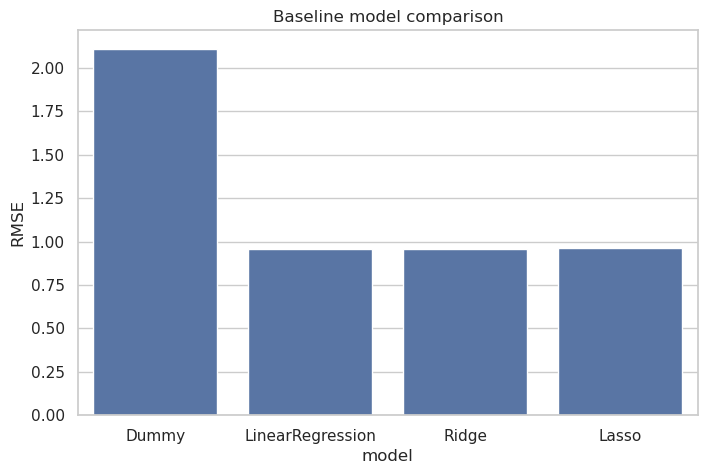

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="model",
    y="RMSE",
)

plt.title("Baseline model comparison")
plt.show()

In [37]:
best_model_name = results_df.sort_values("RMSE").iloc[0]["model"]

best_model_name

'Ridge'

In [39]:
best_model = Ridge(alpha=1.0)

pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", best_model),
    ]
)

pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

MAE: 0.7666804124490253
RMSE: 0.9590700375758809
R2: 0.7941562471731304


## 6. Model comparison

In this section we compare more advanced models for tabular regression.

We evaluate:

- Random Forest
- HistGradientBoosting
- XGBoost (if available)
- MLP Regressor

The goal is to determine whether non-linear models improve performance over the baseline models.
All models are evaluated using cross-validation on the training set.

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

In [41]:
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

xgb_available

True

In [42]:
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

In [43]:
def evaluate_model_cv(name, model, X, y, cv=5):
    pipe = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_my_jobs,
        return_train_score=False,
    )

    result = {
        "model": name,
        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std(),
        "RMSE_mean": -scores["test_rmse"].mean(),
        "RMSE_std": scores["test_rmse"].std(),
        "R2_mean": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std(),
    }

    return result

In [44]:
def evaluate_model_cv(name, model, X, y, cv=5):
    pipe = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_my_jobs,
        return_train_score=False,
    )

    mae_scores = -scores["test_mae"]
    rmse_scores = -scores["test_rmse"]
    r2_scores = scores["test_r2"]

    result = {
        "model": name,
        "MAE_mean": mae_scores.mean(),
        "MAE_std": mae_scores.std(),
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        "R2_mean": r2_scores.mean(),
        "R2_std": r2_scores.std(),
    }

    return result

In [45]:
advanced_models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=n_my_jobs,
    ),
    
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.1,
        max_depth=None,
        random_state=42,
    ),
    
    "MLP": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=200,
        random_state=42,
    ),
}

In [46]:
if xgb_available:
    advanced_models["XGBoost"] = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=n_my_jobs,
        objective="reg:squarederror",
    )

list(advanced_models.keys())

['RandomForest', 'HistGradientBoosting', 'MLP', 'XGBoost']

In [47]:
comparison_results = []

for name, model in advanced_models.items():
    print(f"Evaluating {name}...")
    result = evaluate_model_cv(name, model, X_train, y_train, cv=5)
    comparison_results.append(result)

comparison_results_df = pd.DataFrame(comparison_results)
comparison_results_df.sort_values("RMSE_mean")

Evaluating RandomForest...


KeyboardInterrupt: 

In [ ]:
baseline_comparison_df = results_df.rename(
    columns={
        "MAE": "MAE_mean",
        "RMSE": "RMSE_mean",
        "R2": "R2_mean",
    }
).copy()

baseline_comparison_df["MAE_std"] = np.nan
baseline_comparison_df["RMSE_std"] = np.nan
baseline_comparison_df["R2_std"] = np.nan

all_models_df = pd.concat(
    [
        baseline_comparison_df[
            ["model", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]
        ],
        comparison_results_df[
            ["model", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]
        ],
    ],
    ignore_index=True,
)

all_models_df.sort_values("RMSE_mean")

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=all_models_df.sort_values("RMSE_mean"),
    x="model",
    y="RMSE_mean",
)
plt.title("Model comparison by RMSE")
plt.ylabel("CV RMSE")
plt.xticks(rotation=30)
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=all_models_df.sort_values("R2_mean", ascending=False),
    x="model",
    y="R2_mean",
)
plt.title("Model comparison by R2")
plt.ylabel("CV R2")
plt.xticks(rotation=30)
plt.show()

In [ ]:
best_model_row = all_models_df.sort_values("RMSE_mean").iloc[0]
best_model_row

In [ ]:
best_model_name = best_model_row["model"]
best_model_name

### Model comparison results

The advanced models outperform the baseline linear models, which suggests that the relationship between predictors and the target is not purely linear.

Tree-based models and boosting methods usually perform best on tabular datasets because they can capture:

- non-linear effects
- feature interactions
- heterogeneous relationships across subgroups

If XGBoost or HistGradientBoosting achieves the best score, it will be selected for hyperparameter tuning in the next section.
If Random Forest performs competitively, it can also be used as a strong reference model.

The MLP regressor is included as a neural-network-based benchmark, although neural networks often do not outperform boosting methods on standard tabular data.